In [1]:

print('hello')
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import rc_context

h5ad_file = "/home/catherine/phd/projects/termites/data/znev/combined_no_norm_clustered.h5ad"
adata = sc.read_h5ad(h5ad_file)



hello


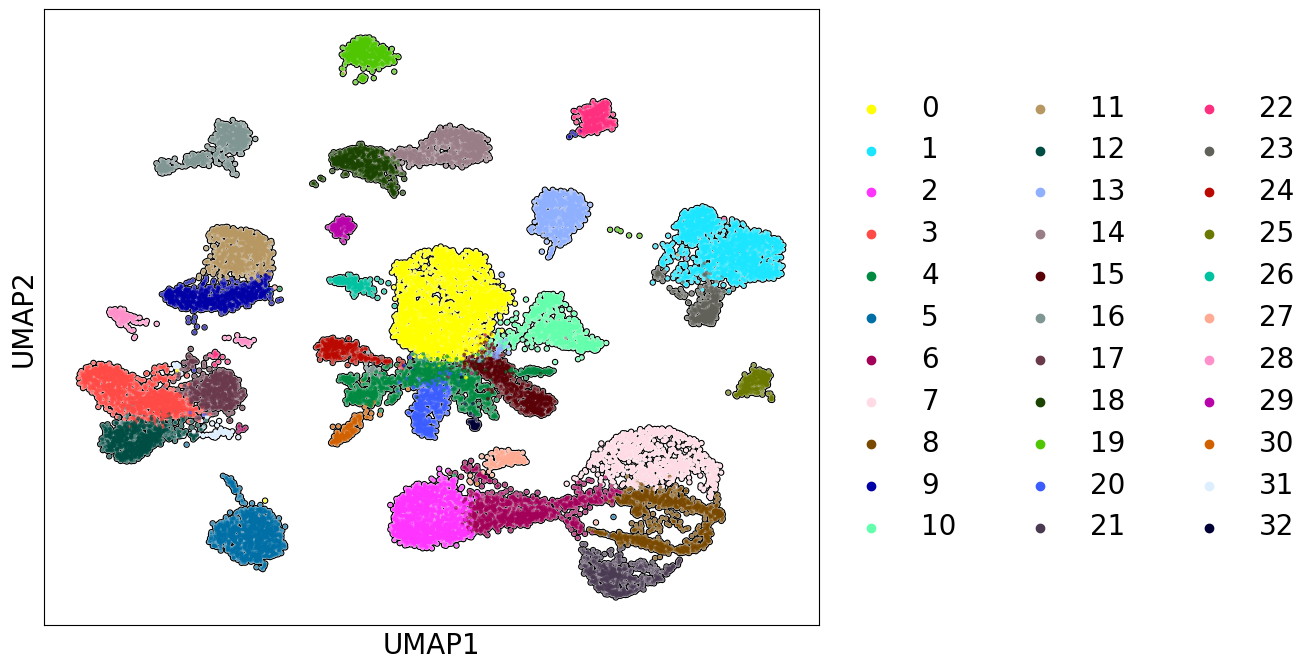

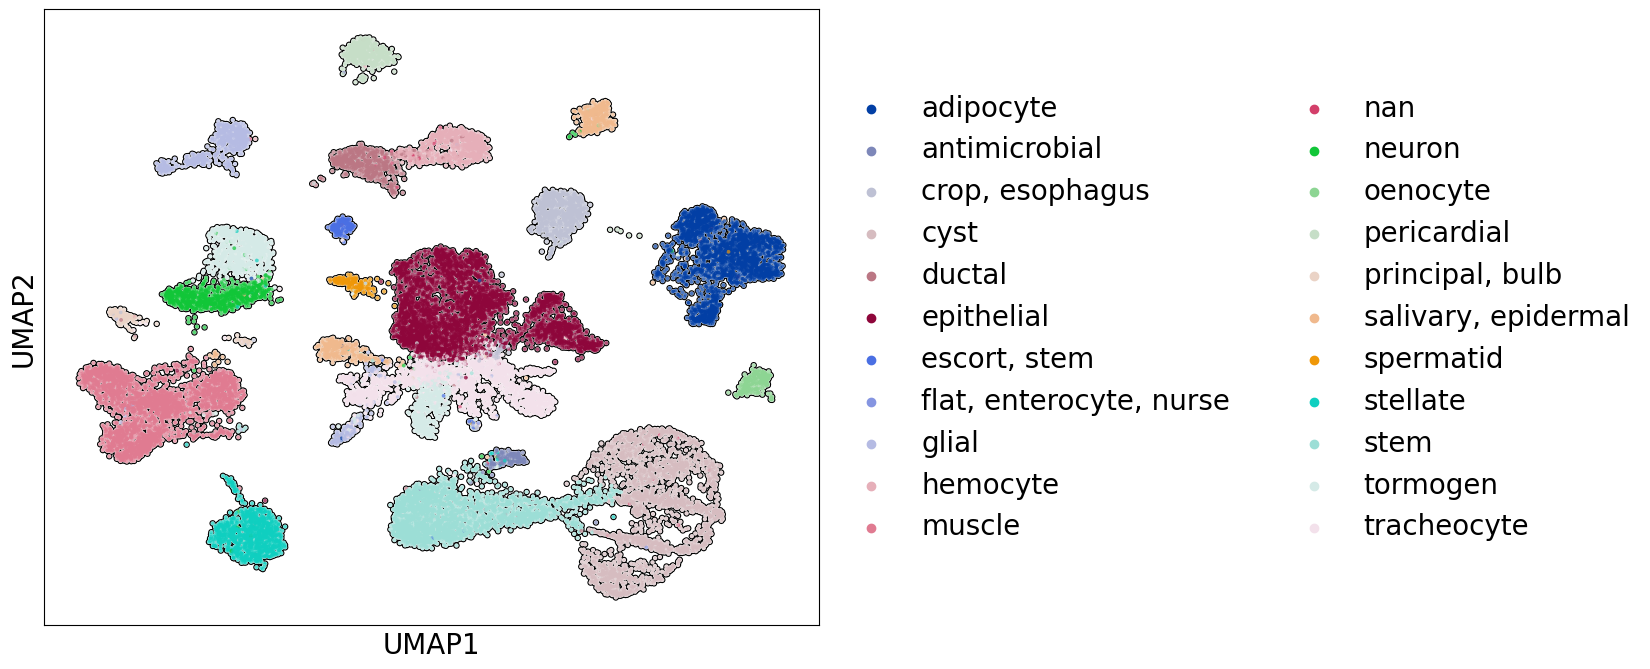

In [2]:
plt.rcParams['figure.figsize'] = (10, 8) 
plt.rcParams['font.size'] = 20          


sc.pl.umap(adata, color='leiden', add_outline=True,
    s=30, title="")
sc.pl.umap(adata, color='leiden_dmel_fabio', add_outline=True,
    s=30, title="")

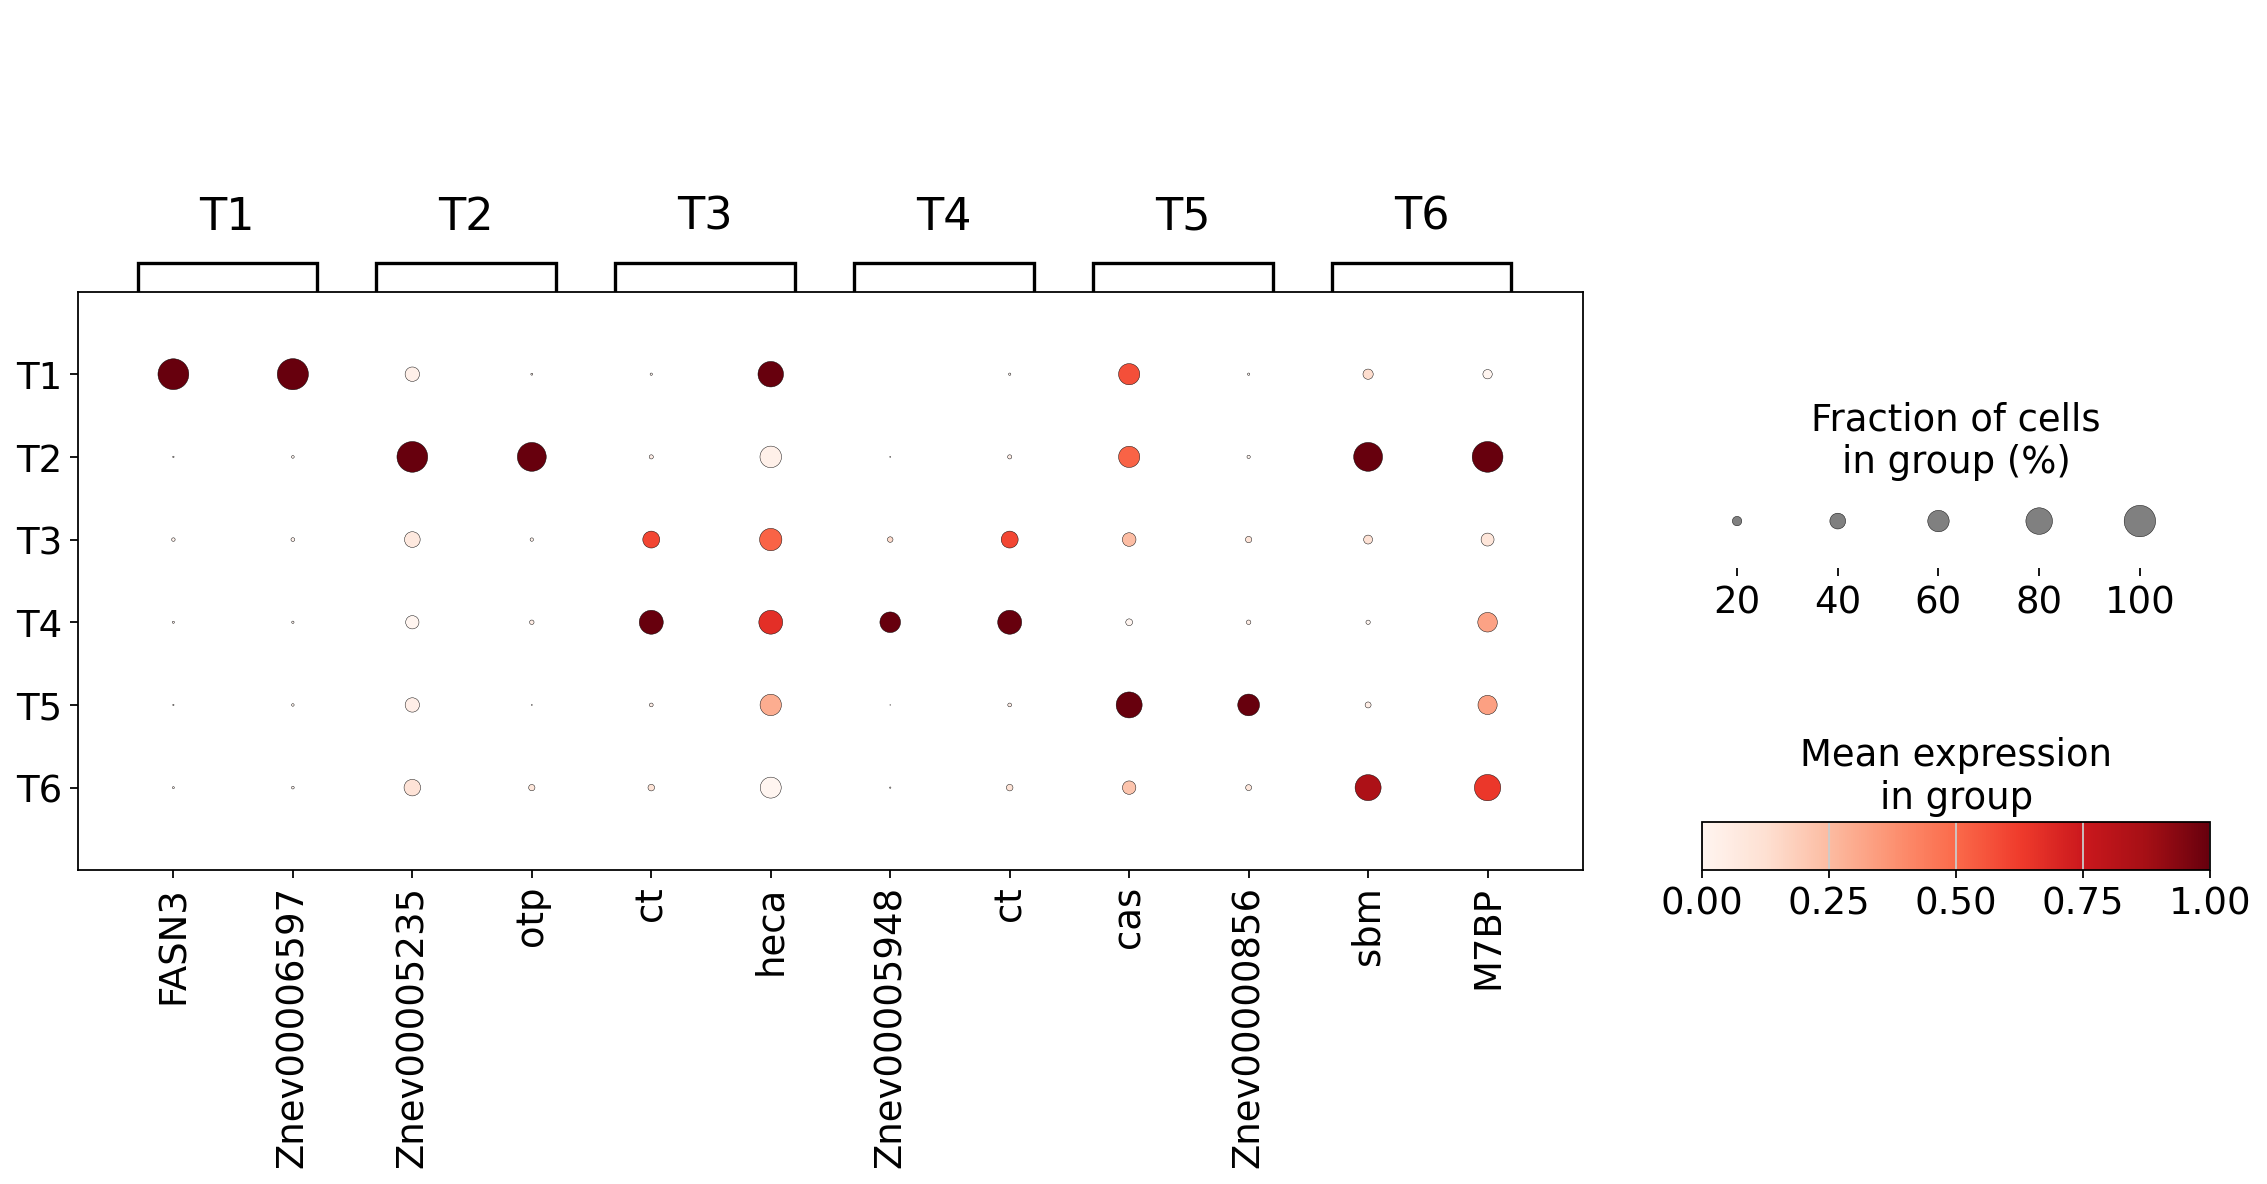

In [7]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- CONFIG --------------------
custom_gene_dict = {
    "T1": ["Znev00002920", "Znev00006597"],
    "T2": ["Znev00005235", "Znev00009086"],
    "T3": ["Znev00003605", "Znev00009320"],
    "T4": ["Znev00005948", "Znev00003605"],
    "T5": ["Znev00010585", "Znev00000856"],
    "T6": ["Znev00003866", "Znev00000008"],
}

FIGSIZE = (14.5, 7.8)


# ----------------- PREP DATA --------------------
cell_types_to_include = list(custom_gene_dict.keys())
adata_subset = adata[adata.obs['paper_cell_type_annotation'].isin(cell_types_to_include)].copy()
adata_subset.obs['paper_cell_type_annotation'] = pd.Categorical(
    adata_subset.obs['paper_cell_type_annotation'],
    categories=cell_types_to_include,
    ordered=True
)

flattened_genes = [g for genes in custom_gene_dict.values() for g in genes]

# Ortholog labels for x-axis genes
display_labels = []
for gene in flattened_genes:
    sym = None
    if gene in adata.var.index and 'dmel_gene_symbol' in adata.var.columns:
        sym = adata.var.loc[gene, 'dmel_gene_symbol']
    display_labels.append(sym if (pd.notna(sym) and sym) else gene)

# Group positions
group_positions = []
start = 0
for ct in custom_gene_dict:
    n = len(custom_gene_dict[ct])
    if n > 0:
        group_positions.append((start, start + n - 1))
        start += n

# Multiline helper: only split if exactly three words
def multiline(name: str) -> str:
    parts = str(name).split()
    if len(parts) == 4:
        return " ".join(parts[:2]) + "\n" + parts[2]
    else:
        return name

# >>> Do NOT wrap cell-type names on the side (y-axis):
pretty_cell_types = cell_types_to_include  # no newlines

# You can still wrap the top gene-group labels if you want:
pretty_group_labels = [multiline(ct) for ct in custom_gene_dict.keys()]

# ------------------- PLOT -----------------------
fig, ax = plt.subplots(figsize=FIGSIZE)

axes_dict = sc.pl.dotplot(
    adata_subset,
    var_names=flattened_genes,
    groupby='paper_cell_type_annotation',
    var_group_positions=group_positions,
    var_group_labels=pretty_group_labels,
    #vmax=1,
    #dot_max=0.3,
    standard_scale='var',
    show=False,
    ax=ax
)

# --- Adjust fonts on all parts ---
main_ax = axes_dict.get("mainplot_ax", None)
if main_ax is not None:
    main_ax.set_xticklabels(display_labels, rotation=90, ha='center')
    # Use unwrapped cell-type names on the side
    main_ax.set_yticklabels(pretty_cell_types)



plt.tight_layout()
plt.show()
